#  Image Autoencoder (Keras)

This project demonstrates a **Convolutional Autoencoder** built with TensorFlow/Keras.  
It learns to compress and reconstruct an image, showing how reconstruction improves over epochs.

###  Features:
- Train a convolutional autoencoder
- Visualize reconstruction at multiple epochs
- Works for both grayscale and RGB images

---


##  Import Libraries


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
from google.colab import files
import requests
from io import BytesIO


##Load an Image (Upload or URL)
You can upload an image or provide a URL to load automatically.


In [13]:
def load_image():
    choice = input("Type 'url' to enter image URL or 'upload' to upload from device: ").strip().lower()

    if choice == 'url':
        url = input("Enter image URL: ").strip()
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    elif choice == 'upload':
        uploaded = files.upload()
        img_path = list(uploaded.keys())[0]
        img = Image.open(img_path).convert('RGB')
    else:
        print("Invalid choice!")
        return None

    img = img.resize((128, 128))

    if img.mode == 'L':
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)
    else:
        img_array = img_to_array(img) / 255.0

    img_array = np.expand_dims(img_array, axis=0)
    return img_array


##  Build the Autoencoder Model

In [16]:
# Build autoencoder function
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

def build_autoencoder(channels):
    input_img = Input(shape=(128, 128, channels))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(channels, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(0.001), loss='mse')
    return autoencoder




## Train the Model and Reconstruct Images

Type 'url' to enter image URL or 'upload' to upload from device: upload


Saving istockphoto-1439436349-612x612.jpg to istockphoto-1439436349-612x612 (2).jpg

Training from 0 to 5 epochs (5 epochs)...
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.1797Epoch 1 loss: 0.179660
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1797
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1650Epoch 2 loss: 0.164977
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.1650
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1463Epoch 3 loss: 0.146294
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.1463
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1227Epoch 4 loss: 0.122666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1227
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.1145Epoch 5 loss: 0.114478
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.1145
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step

Training from 5 to 20 epochs (15 epochs)...
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0976Epoch 6 loss: 0.097564
1/1 ━━━━━━

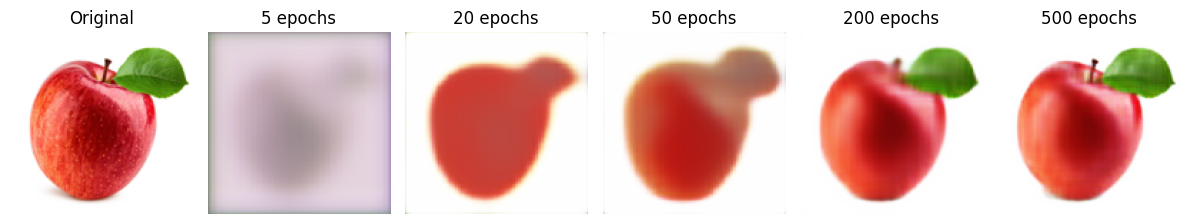

In [21]:
from tensorflow.keras.callbacks import LambdaCallback

# --- Load image & build model (run these first) ---
img_array = load_image()
if img_array is None:
    raise Exception("No image loaded. Re-run the load cell and upload or give a URL.")

channels = img_array.shape[-1]
autoencoder = build_autoencoder(channels)

# --- Training with explicit loss collection and printing ---
epochs_list = [5, 20, 50, 200,500]   # adjust as needed
reconstructed_images = []
current_epochs = 0
loss_history = []

# simple callback to print loss per epoch in training output
print_loss_cb = LambdaCallback(on_epoch_end=lambda epoch, logs: print(f"Epoch {current_epochs + epoch + 1} loss: {logs.get('loss'):.6f}"))

for target in epochs_list:
    n_epochs = target - current_epochs
    if n_epochs <= 0:
        current_epochs = target
        continue

    print(f"\nTraining from {current_epochs} to {target} epochs ({n_epochs} epochs)...")
    history = autoencoder.fit(
        img_array, img_array,
        epochs=n_epochs,
        batch_size=1,
        verbose=1,
        callbacks=[print_loss_cb]
    )
    # append the per-epoch losses to the master loss_history
    loss_history.extend(history.history.get('loss', []))

    current_epochs = target
    recon = autoencoder.predict(img_array)[0]
    reconstructed_images.append((target, recon))

# --- print collected loss list for debugging ---
print("\nCollected loss_history (per epoch):")
print(loss_history)

# --- Plot original + reconstructions ---
plt.figure(figsize=(12, 4))
plt.subplot(1, len(reconstructed_images) + 1, 1)
plt.title("Original")
if channels == 1:
    plt.imshow(img_array[0, :, :, 0], cmap='gray')
else:
    plt.imshow(img_array[0])
plt.axis('off')

for i, (ep, recon) in enumerate(reconstructed_images):
    plt.subplot(1, len(reconstructed_images) + 1, i + 2)
    plt.title(f"{ep} epochs")
    if channels == 1:
        plt.imshow(recon[:, :, 0], cmap='gray')
    else:
        plt.imshow(recon)
    plt.axis('off')

plt.tight_layout()
plt.show()




In [22]:
from PIL import Image
import numpy as np

# save original
orig = (img_array[0] * 255).astype(np.uint8)
Image.fromarray(orig.squeeze()).save("original_example.png")

# save last reconstruction
recon = (reconstructed_images[-1][1] * 255).astype(np.uint8)
Image.fromarray(recon.squeeze()).save("reconstruction_example.png")
